# Homework 3 | Survival Analysis & CLV

> by: Albert Hakobyan

Survival analysis on a telecom churn dataset using parametric AFT models, model comparison, feature selection, CLV estimation, and a business report on retention strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from lifelines import (WeibullAFTFitter,
                        LogNormalAFTFitter,
                        LogLogisticAFTFitter,
                        KaplanMeierFitter)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (20, 8)

## 1. Data Loading & Exploration

In [2]:
df = pd.read_csv("telco.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 15)


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        1000 non-null   int64 
 1   region    1000 non-null   object
 2   tenure    1000 non-null   int64 
 3   age       1000 non-null   int64 
 4   marital   1000 non-null   object
 5   address   1000 non-null   int64 
 6   income    1000 non-null   int64 
 7   ed        1000 non-null   object
 8   retire    1000 non-null   object
 9   gender    1000 non-null   object
 10  voice     1000 non-null   object
 11  internet  1000 non-null   object
 12  forward   1000 non-null   object
 13  custcat   1000 non-null   object
 14  churn     1000 non-null   object
dtypes: int64(5), object(10)
memory usage: 117.3+ KB


In [4]:
df.describe()

,ID,tenure,age,address,income
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,35.526000,41.684000,11.551000,77.535000
std,288.819436,21.359812,12.558816,10.086681,107.044165
min,1.000000,1.000000,18.000000,0.000000,9.000000
25%,250.750000,17.000000,32.000000,3.000000,29.000000
50%,500.500000,34.000000,40.000000,9.000000,47.000000
75%,750.250000,54.000000,51.000000,18.000000,83.000000
max,1000.000000,72.000000,77.000000,55.000000,1668.000000


In [5]:
df.isnull().sum()

ID          0
region      0
tenure      0
age         0
marital     0
address     0
income      0
ed          0
retire      0
gender      0
voice       0
internet    0
forward     0
custcat     0
churn       0
dtype: int64

In [6]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].unique()}")

region: ['Zone 2' 'Zone 3' 'Zone 1']
marital: ['Married' 'Unmarried']
ed: ['College degree' 'Post-undergraduate degree'
 'Did not complete high school' 'High school degree' 'Some college']
retire: ['No' 'Yes']
gender: ['Male' 'Female']
voice: ['No' 'Yes']
internet: ['No' 'Yes']
forward: ['Yes' 'No']
custcat: ['Basic service' 'Total service' 'Plus service' 'E-service']
churn: ['Yes' 'No']


### Encoding Categorical Variables

Binary categoricals are label-encoded. Multi-level categoricals are one-hot encoded with the first level dropped.

In [7]:
df_model = df.copy()

label_maps = {
    "marital":  {"Unmarried": 0, "Married": 1},
    "retire":   {"No": 0, "Yes": 1},
    "gender":   {"Male": 0, "Female": 1},
    "voice":    {"No": 0, "Yes": 1},
    "internet": {"No": 0, "Yes": 1},
    "forward":  {"No": 0, "Yes": 1},
}

for col, mapping in label_maps.items():
    if col in df_model.columns and df_model[col].dtype == "object":
        df_model[col] = df_model[col].map(mapping)

for col in ["ed", "custcat", "region"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str)
        df_model = pd.get_dummies(df_model, columns=[col], drop_first=True, dtype=int)

if "ID" in df_model.columns:
    df_model = df_model.drop(columns=["ID"])

df_model.head()

,tenure,age,marital,address,income,retire,gender,voice,internet,forward,churn,ed_Did not complete high school,ed_High school degree,ed_Post-undergraduate degree,ed_Some college,custcat_E-service,custcat_Plus service,custcat_Total service,region_Zone 2,region_Zone 3
0,13,44,1,9,64,0,0,0,0,1,Yes,0,0,0,0,0,0,0,1,0
1,11,33,1,7,136,0,0,1,0,1,Yes,0,0,1,0,0,0,1,0,1
2,68,52,1,24,116,0,1,0,0,0,No,1,0,0,0,0,1,0,0,1
3,33,33,0,12,33,0,1,0,0,0,Yes,0,1,0,0,0,0,0,1,0
4,23,30,1,9,30,0,0,0,0,1,No,1,0,0,0,0,1,0,1,0


## 2. Kaplan-Meier Baseline

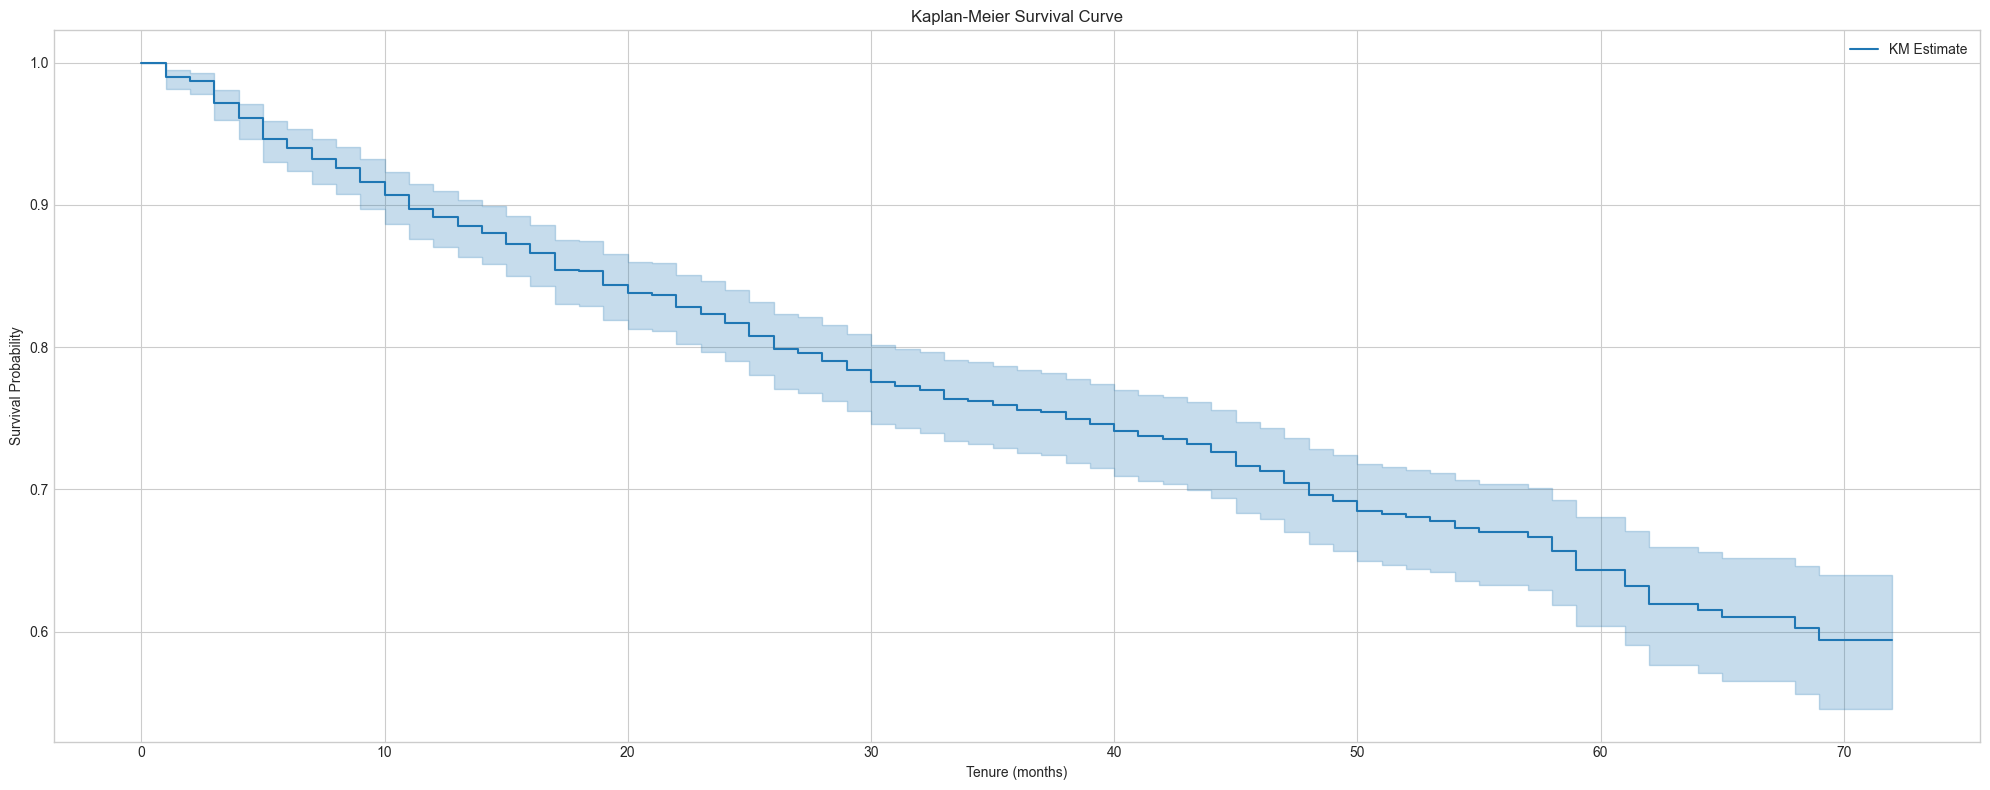

Median survival time: inf months


In [8]:
df_model['churn'] = df_model['churn'].map({'Yes': 1, 'No': 0})


kmf = KaplanMeierFitter()
kmf.fit(df_model["tenure"], event_observed=df_model["churn"], label="KM Estimate")

fig, ax = plt.subplots()
kmf.plot_survival_function(ax=ax)
ax.set_title("Kaplan-Meier Survival Curve")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival Probability")
plt.tight_layout()
plt.show()

print(f"Median survival time: {kmf.median_survival_time_:.2f} months")

## 3. Parametric AFT Models

Fitting Weibull, Log-Normal, and Log-Logistic AFT models with all covariates.

In [9]:
DURATION = "tenure"
EVENT = "churn"

aft_specs = {
    "Weibull":      WeibullAFTFitter(penalizer=0.01),
    "Log-Normal":   LogNormalAFTFitter(penalizer=0.01),
    "Log-Logistic": LogLogisticAFTFitter(penalizer=0.01),
}

fitted = {}
metrics = []

for name, fitter in aft_specs.items():
    fitter.fit(df_model, duration_col=DURATION, event_col=EVENT)
    fitted[name] = fitter
    metrics.append({
        "Model": name,
        "AIC": round(fitter.AIC_, 2),
        "BIC": round(fitter.BIC_, 2),
        "Log-Likelihood": round(fitter.log_likelihood_, 2),
        "Concordance": round(fitter.concordance_index_, 4),
    })
    print(f"\n{'='*60}")
    print(f"{name} AFT")
    print(f"{'='*60}")
    fitter.print_summary(columns=["coef", "exp(coef)", "p"])


Weibull AFT


<lifelines.WeibullAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1467.07
         time fit was run = 2026-05-05 23:11:53 UTC

---
                                         coef exp(coef)      p
param   covariate                                             
lambda_ address                          0.04      1.04 <0.005
        age                              0.03      1.03 <0.005
        custcat_E-service                0.90      2.45 <0.005
        custcat_Plus service             0.66      1.93 <0.005
        custcat_Total service            0.85      2.35 <0.005
        ed_Did not complete high school  0.41      1.50   0.03
        ed_High school degree            0.30      1.34   0.03
        ed_Post-undergraduate degree     0.18      1.20   0.32
        ed_Some college                  0.23      1.26   0.10
        forward                         -0.06      0.95   0.69
        gender                          -0.00      1.00   0.97
        income                           0.00      1.00   0.22
        internet                        -0.73      0.48 <0.005
        marital                          0.34      1.41 <0.005
        region_Zone 2                   -0.06      0.94   0.63
        region_Zone 3                    0.11      1.12   0.37
        retire                           0.19      1.21   0.69
        voice                           -0.29      0.75   0.04
        Intercept                        2.51     12.25 <0.005
rho_    Intercept                        0.18      1.20 <0.005
---
Concordance = 0.78
AIC = 2974.15
log-likelihood ratio test = 278.71 on 18 df
-log2(p) of ll-ratio test = 159.28


Log-Normal AFT


<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1463.22
         time fit was run = 2026-05-05 23:11:53 UTC

---
                                        coef exp(coef)      p
param  covariate                                             
mu_    address                          0.04      1.04 <0.005
       age                              0.03      1.03 <0.005
       custcat_E-service                0.97      2.63 <0.005
       custcat_Plus service             0.78      2.18 <0.005
       custcat_Total service            0.98      2.66 <0.005
       ed_Did not complete high school  0.34      1.40   0.07
       ed_High school degree            0.29      1.33   0.06
       ed_Post-undergraduate degree    -0.05      0.95   0.82
       ed_Some college                  0.24      1.27   0.13
       forward                         -0.11      0.90   0.51
       gender                          -0.05      0.95   0.68
       income                           0.00      1.00   0.10
       internet                        -0.73      0.48 <0.005
       marital                          0.44      1.56 <0.005
       region_Zone 2                   -0.09      0.91   0.51
       region_Zone 3                    0.04      1.04   0.77
       retire                           0.05      1.05   0.90
       voice                           -0.37      0.69   0.02
       Intercept                        2.04      7.70 <0.005
sigma_ Intercept                        0.26      1.30 <0.005
---
Concordance = 0.79
AIC = 2966.44
log-likelihood ratio test = 278.59 on 18 df
-log2(p) of ll-ratio test = 159.20


Log-Logistic AFT


<lifelines.LogLogisticAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1464.26
         time fit was run = 2026-05-05 23:11:53 UTC

---
                                        coef exp(coef)      p
param  covariate                                             
alpha_ address                          0.04      1.04 <0.005
       age                              0.03      1.03 <0.005
       custcat_E-service                0.94      2.57 <0.005
       custcat_Plus service             0.73      2.09 <0.005
       custcat_Total service            1.00      2.71 <0.005
       ed_Did not complete high school  0.40      1.49   0.04
       ed_High school degree            0.31      1.36   0.04
       ed_Post-undergraduate degree    -0.04      0.96   0.86
       ed_Some college                  0.21      1.23   0.16
       forward                         -0.11      0.89   0.47
       gender                          -0.03      0.97   0.77
       income                           0.00      1.00   0.20
       internet                        -0.75      0.47 <0.005
       marital                          0.43      1.54 <0.005
       region_Zone 2                   -0.05      0.96   0.73
       region_Zone 3                    0.10      1.11   0.43
       retire                           0.10      1.11   0.82
       voice                           -0.35      0.71   0.03
       Intercept                        2.02      7.57 <0.005
beta_  Intercept                        0.34      1.41 <0.005
---
Concordance = 0.79
AIC = 2968.53
log-likelihood ratio test = 281.89 on 18 df
-log2(p) of ll-ratio test = 161.44

### Model Comparison

In [10]:
comparison = pd.DataFrame(metrics).set_index("Model")
comparison.style.highlight_min(subset=["AIC", "BIC"], color="lightgreen").highlight_max(subset=["Concordance"], color="lightgreen")

,AIC,BIC,Log-Likelihood,Concordance
Model,,,,
Weibull,2974.150000,2947.960000,-1467.070000,0.783400
Log-Normal,2966.440000,2940.260000,-1463.220000,0.786300
Log-Logistic,2968.530000,2942.340000,-1464.260000,0.786300


### Survival Curves — All Models on One Plot

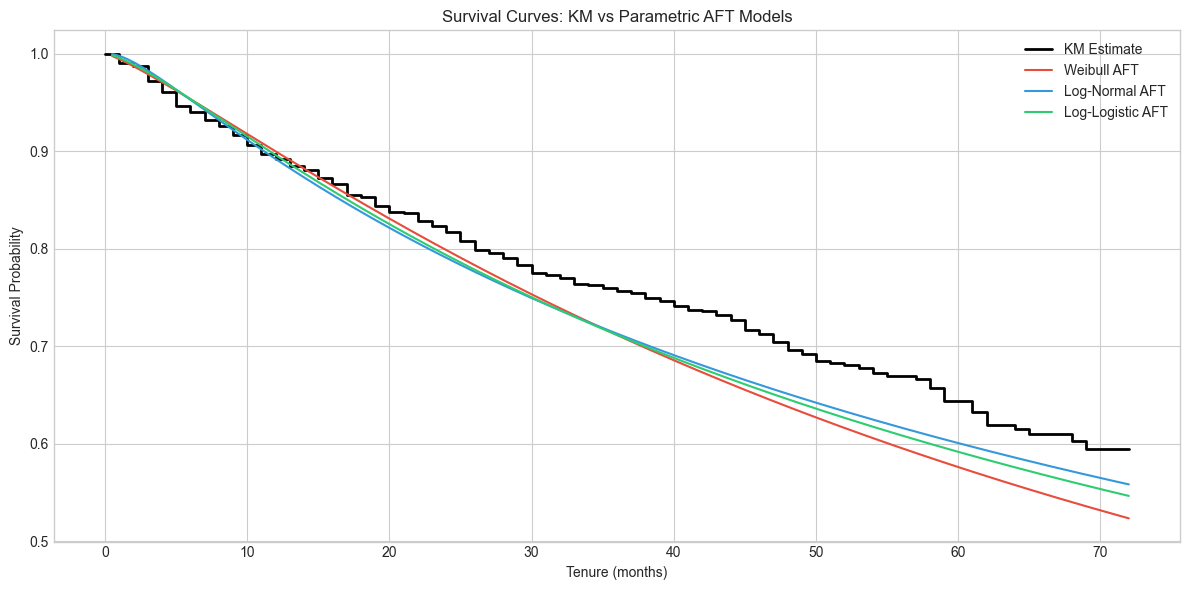

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
kmf.plot_survival_function(ax=ax, ci_show=False, color="black", linewidth=2)

palette = {"Weibull": "#e74c3c", "Log-Normal": "#3498db", "Log-Logistic": "#2ecc71"}
t_grid = np.linspace(0.5, df_model[DURATION].max(), 300)

for name, mdl in fitted.items():
    avg_surv = mdl.predict_survival_function(df_model, times=t_grid).mean(axis=1)
    ax.plot(t_grid, avg_surv, label=f"{name} AFT", color=palette[name], linewidth=1.5)

ax.set_title("Survival Curves: KM vs Parametric AFT Models")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival Probability")
ax.legend()
plt.tight_layout()
plt.show()

### Model Selection

We select the model with the lowest AIC. Beyond AIC, as a decision-maker we also consider:
- **Hazard shape:** Log-Logistic allows non-monotone (hump-shaped) hazards, realistic for churn where risk first rises then falls for loyal customers. Weibull only permits monotone hazards.
- **Tail behavior:** Log-Normal and Log-Logistic have heavier tails, better capturing long-tenured subscribers.
- **Interpretability:** AFT coefficients directly quantify how each feature accelerates or decelerates time-to-churn.

In [12]:
best_name = comparison["AIC"].idxmin()
print(f"Best model by AIC: {best_name}")
best_aft = fitted[best_name]

Best model by AIC: Log-Normal


## 4. Feature Selection

Refitting the best model with only statistically significant features (p < 0.05).

In [13]:
summary_df = best_aft.summary
sig_rows = summary_df[summary_df["p"] < 0.05]
sig_features = list({idx[1] for idx in sig_rows.index if idx[1] not in ["Intercept", "_intercept"]})
print(f"Significant features ({len(sig_features)}): {sorted(sig_features)}")

keep = [c for c in sig_features + [DURATION, EVENT] if c in df_model.columns]
df_final = df_model[keep].copy()

Significant features (8): ['address', 'age', 'custcat_E-service', 'custcat_Plus service', 'custcat_Total service', 'internet', 'marital', 'voice']


### Final Model

In [14]:
model_map = {
    "Weibull":      WeibullAFTFitter,
    "Log-Normal":   LogNormalAFTFitter,
    "Log-Logistic": LogLogisticAFTFitter,
}

final_model = model_map[best_name](penalizer=0.01)
final_model.fit(df_final, duration_col=DURATION, event_col=EVENT)
final_model.print_summary(columns=["coef", "exp(coef)", "p"])

print(f"\nAIC:     {final_model.AIC_:.2f}")
print(f"BIC:     {final_model.BIC_:.2f}")
print(f"C-index: {final_model.concordance_index_:.4f}")

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1467.87
         time fit was run = 2026-05-05 23:11:53 UTC

---
                              coef exp(coef)      p
param  covariate                                   
mu_    address                0.04      1.04 <0.005
       age                    0.04      1.04 <0.005
       custcat_E-service      0.93      2.54 <0.005
       custcat_Plus service   0.75      2.11 <0.005
       custcat_Total service  0.87      2.40 <0.005
       internet              -0.79      0.45 <0.005
       marital                0.44      1.55 <0.005
       voice                 -0.40      0.67   0.01
       Intercept              2.16      8.63 <0.005
sigma_ Intercept              0.27      1.31 <0.005
---
Concordance = 0.78
AIC = 2955.75
log-likelihood ratio test = 269.29 on 8 df
-log2(p) of ll-ratio test = 175.58


AIC:     2955.75
BIC:     2949.56
C-index: 0.7811


## 5. CLV Calculation

Using the CLV formula from the slides:

$$CLV_i = \sum_{t=1}^{T} \frac{m \cdot S_i(t)}{(1 + d)^t}$$

where $S_i(t)$ is the predicted survival probability for customer $i$ at month $t$, $m$ is the monthly margin (revenue minus cost), and $d$ is the monthly discount rate.

In [15]:
MONTHLY_REVENUE = 50
MONTHLY_COST = 30
MARGIN = MONTHLY_REVENUE - MONTHLY_COST
ANNUAL_DISCOUNT = 0.10
MONTHLY_DISCOUNT = ANNUAL_DISCOUNT / 12
HORIZON = 72

t_range = np.arange(1, HORIZON + 1)
surv_matrix = final_model.predict_survival_function(df_final, times=t_range)
discounts = np.array([1 / (1 + MONTHLY_DISCOUNT) ** t for t in t_range])

clv_values = (surv_matrix.values * MARGIN * discounts.reshape(-1, 1)).sum(axis=0)
df["CLV"] = clv_values

print("CLV distribution:")
df["CLV"].describe().round(2)

CLV distribution:


count    1000.00
mean      816.96
std       190.33
min       194.86
25%       679.72
50%       847.59
75%       983.29
max      1078.74
Name: CLV, dtype: float64

>For the purpose of the experiments, I am assuming a monthly revenue of $\$50$ per subscriber and a monthly servicing cost of $\$30$ (covering network, support, and billing overhead), yielding a $\$20$ monthly margin. These figures approximate industry-average ARPU and operating costs for a mid-tier telecom provider and are used consistently across all CLV calculations.

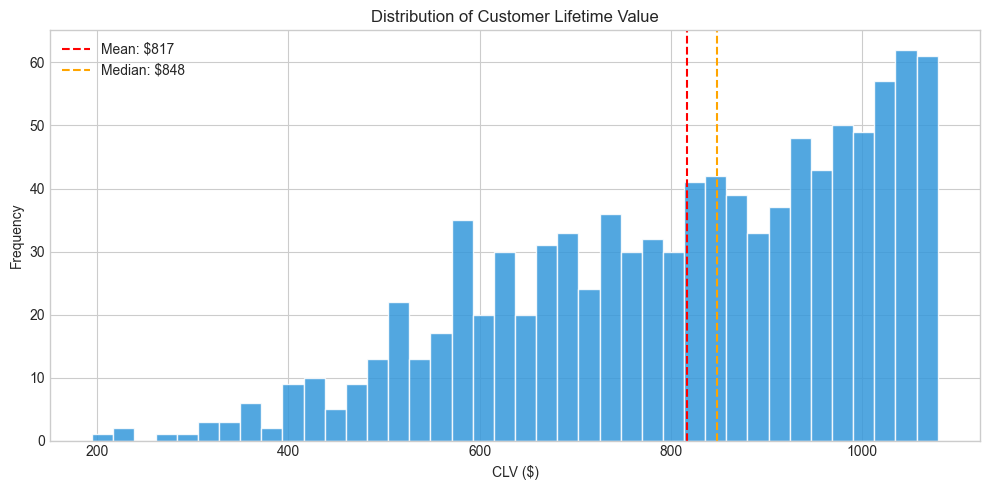

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["CLV"], bins=40, edgecolor="white", color="#3498db", alpha=0.85)
ax.axvline(df["CLV"].mean(), color="red", linestyle="--", label=f"Mean: ${df['CLV'].mean():.0f}")
ax.axvline(df["CLV"].median(), color="orange", linestyle="--", label=f"Median: ${df['CLV'].median():.0f}")
ax.set_title("Distribution of Customer Lifetime Value")
ax.set_xlabel("CLV ($)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 6. CLV Across Segments

In [17]:
seg_cols = [c for c in ["gender", "marital", "custcat", "internet", "voice", "forward", "retire"] if c in df.columns]

for col in seg_cols:
    print(f"\n--- CLV by {col} ---")
    print(df.groupby(col)["CLV"].agg(["mean", "median", "count"]).round(2))
    print()


--- CLV by gender ---
          mean  median  count
gender                       
Female  815.21  834.91    517
Male    818.84  855.68    483


--- CLV by marital ---
             mean  median  count
marital                         
Married    862.66  896.52    495
Unmarried  772.18  792.79    505


--- CLV by custcat ---
                 mean  median  count
custcat                             
Basic service  700.21  691.84    266
E-service      879.92  902.95    217
Plus service   923.88  955.07    281
Total service  763.37  775.24    236


--- CLV by internet ---
            mean  median  count
internet                       
No        884.09  924.45    632
Yes       701.68  711.02    368


--- CLV by voice ---
         mean  median  count
voice                       
No     843.21  877.12    696
Yes    756.89  770.11    304


--- CLV by forward ---
           mean  median  count
forward                       
No       789.16  809.70    507
Yes      845.56  882.89    493


--- CLV b

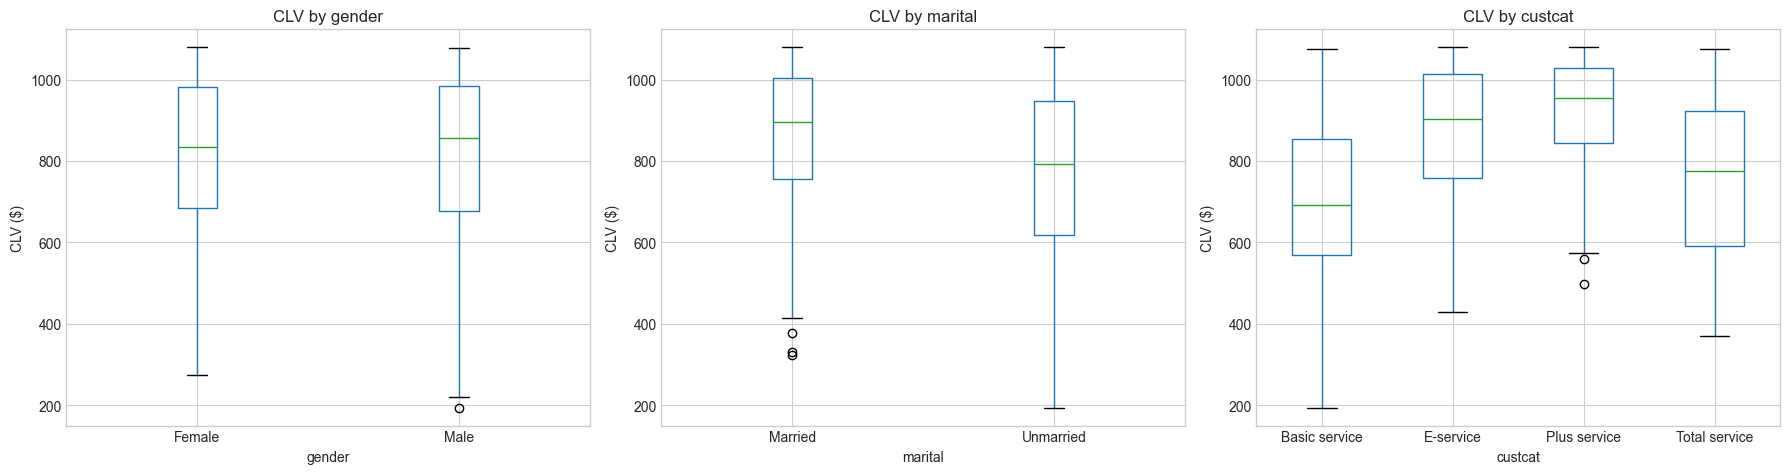

In [18]:
n_plots = min(3, len(seg_cols))
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, col in zip(axes, seg_cols[:n_plots]):
    df.boxplot(column="CLV", by=col, ax=ax)
    ax.set_title(f"CLV by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("CLV ($)")

plt.suptitle("")
plt.tight_layout()
plt.show()

### CLV Quartile Segments

In [19]:
df["clv_segment"] = pd.qcut(df["CLV"], q=4, labels=["Low", "Medium", "High", "VIP"])
df.groupby("clv_segment")["CLV"].agg(["mean", "median", "count", "sum"]).round(2)

,mean,median,count,sum
clv_segment,,,,
Low,550.77,574.84,251,138243.04
Medium,767.65,769.37,249,191143.93
High,917.48,920.52,250,229370.00
VIP,1032.83,1033.80,250,258207.36


In [20]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

segment_profile = df.groupby("clv_segment").agg(
                    avg_tenure=("tenure", "mean"),
                    avg_income=("income", "mean"),
                    avg_age=("age", "mean"),
                    avg_address=("address", "mean"),
                    churn_rate=("churn", "mean"),
                    count=("CLV", "count")).round(2)
segment_profile

,avg_tenure,avg_income,avg_age,avg_address,churn_rate,count
clv_segment,,,,,,
Low,20.33,43.11,30.20,4.12,0.47,251
Medium,28.85,59.67,36.65,7.04,0.35,249
High,39.37,88.64,44.94,11.36,0.20,250
VIP,53.59,118.79,54.98,23.70,0.08,250


## 7. Annual Retention Budget

We compute each subscriber's conditional probability of churning within the next 12 months and flag those exceeding 50% as at-risk. The retention budget is set at 10% of total at-risk CLV.

In [21]:
tenures = df_final[DURATION].values
s_now_list, s_fut_list = [], []

for i in range(len(df_final)):
    row = df_final.iloc[[i]]
    t0 = max(tenures[i], 1)
    t1 = tenures[i] + 12
    s0 = final_model.predict_survival_function(row, times=[t0]).values[0, 0]
    s1 = final_model.predict_survival_function(row, times=[t1]).values[0, 0]
    s_now_list.append(s0)
    s_fut_list.append(s1)

df["surv_current"] = s_now_list
df["surv_12m"] = s_fut_list
df["cond_churn_12m"] = 1 - (df["surv_12m"] / df["surv_current"])

at_risk = df[df["cond_churn_12m"] > 0.5]
total_at_risk_clv = at_risk["CLV"].sum()
budget = total_at_risk_clv * 0.10

print(f"Total subscribers:          {len(df)}")
print(f"At-risk subscribers:        {len(at_risk)} ({len(at_risk)/len(df)*100:.1f}%)")
print(f"Total at-risk CLV:          ${total_at_risk_clv:,.0f}")
print(f"Annual retention budget:    ${budget:,.0f}")

Total subscribers:          1000
At-risk subscribers:        6 (0.6%)
Total at-risk CLV:          $1,556
Annual retention budget:    $156


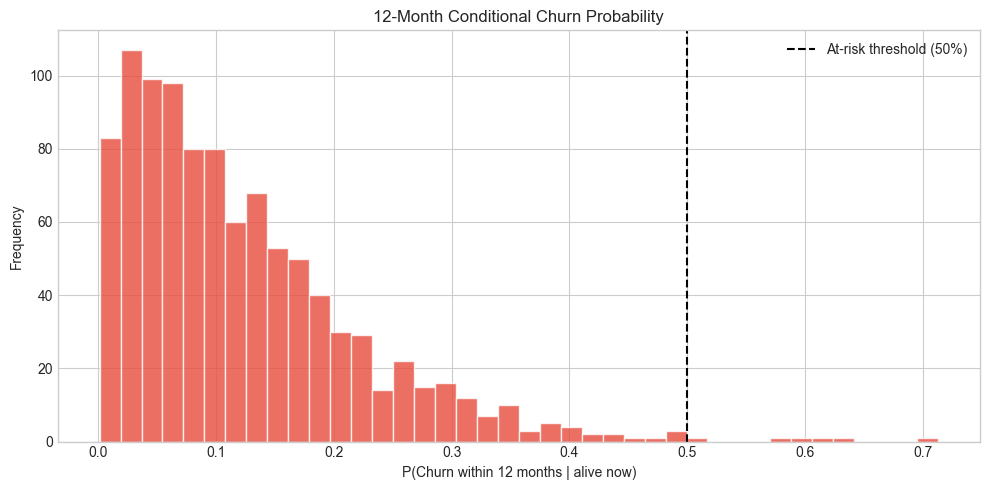

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["cond_churn_12m"], bins=40, edgecolor="white", color="#e74c3c", alpha=0.8)
ax.axvline(0.5, color="black", linestyle="--", label="At-risk threshold (50%)")
ax.set_title("12-Month Conditional Churn Probability")
ax.set_xlabel("P(Churn within 12 months | alive now)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

The histogram above shows the conditional probability of each subscriber churning within the next 12 months, given that they are still active at their current tenure. The vast majority of subscribers fall well below the 50% threshold, indicating relatively low near-term churn risk across the base. Only 6 subscribers (0.6%) exceed the at-risk cutoff, which is consistent with the model's finding that most customers have already survived past their highest-hazard period. The right-skewed shape confirms that while a small tail of subscribers faces elevated churn probability, the overall portfolio is stable in the short term.

---

## Report

The Log-Normal AFT model was selected as the final model based on the lowest AIC (2955.75) and a concordance index of 0.78. Eight covariates were statistically significant. In the AFT framework, positive coefficients indicate longer expected survival (slower churn): being married (coef = 0.44) extends time-to-churn by roughly 55%, older age and longer address tenure each contribute modestly (4% per unit), and premium customer categories — E-service (exp(coef) = 2.54), Plus service (2.11), and Total service (2.40) — substantially extend subscriber lifetimes relative to Basic service. Conversely, having internet service (coef = −0.79, exp(coef) = 0.45) cuts expected tenure by more than half, and voice service (coef = −0.40, exp(coef) = 0.67) reduces it by about a third. These negative coefficients suggest that subscribers actively using network-intensive services experience higher churn, possibly due to service-quality sensitivity or competitive switching.

We define the most valuable subscribers as those combining high CLV with low churn risk. The VIP quartile (mean CLV = $\$1,033$) is characterized by older, married, long-tenured customers without internet service, carrying only an $8\%$ churn rate. By contrast, the Low segment (mean CLV = $\$551$) consists of younger, unmarried, short-tenured internet subscribers with a 47% churn rate. Assuming this dataset represents the population, we computed each subscriber's conditional probability of churning within 12 months given their current tenure. Only 6 subscribers ($0.6\%$) exceed the $50\%$ at-risk threshold, yielding a total at-risk CLV of $\$1,556$ and a recommended annual retention budget of approximately $\$156$ ($10\%$ of at-risk CLV). This low figure reflects the model's finding that most surviving subscribers have already passed through their highest-hazard window. Beyond budget allocation, we recommend proactive engagement for internet and voice subscribers during their first 12 months (when hazard peaks), loyalty rewards for the married/older demographic to reinforce their already strong retention, targeted bundling strategies to shift Basic service users toward Plus or E-service tiers, and periodic re-scoring of churn probabilities as new tenure data accumulates.